In [40]:
import numpy as np
import pandas as pd

In [41]:
df = pd.read_csv('spam.csv', encoding = 'latin1')

In [42]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
1,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
2,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
3,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN
4,spam,"SIX chances to win CASH! From 100 to 20,000 po...",NaN,NaN,NaN


DATA CLEANING

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8828 entries, 0 to 8827
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          8828 non-null   str  
 1   v2          8828 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 345.0 KB


In [44]:
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [45]:
df.sample(3)

,v1,v2
35,spam,Text & meet someone sexy today. U can find a d...
6471,ham,I am not at all happy with what you saying or ...
2387,spam,on thursday NUMBER september NUMBER NUMBER NUM...


In [46]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [47]:
df.head()

,target,text
0,spam,Free entry in 2 a wkly comp to win FA Cup fina...
1,spam,FreeMsg Hey there darling it's been 3 week's n...
2,spam,WINNER!! As a valued network customer you have...
3,spam,Had your mobile 11 months or more? U R entitle...
4,spam,"SIX chances to win CASH! From 100 to 20,000 po..."


In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
encoder = LabelEncoder()

In [50]:
df['target'] = encoder.fit_transform(df['target'])

In [51]:
df.head()

,target,text
0,1,Free entry in 2 a wkly comp to win FA Cup fina...
1,1,FreeMsg Hey there darling it's been 3 week's n...
2,1,WINNER!! As a valued network customer you have...
3,1,Had your mobile 11 months or more? U R entitle...
4,1,"SIX chances to win CASH! From 100 to 20,000 po..."


In [52]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(969)

In [54]:
df = df.drop_duplicates(keep = 'first')

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.shape

(7859, 2)

EDA 

In [57]:
df['target'].value_counts()

target
0    4516
1    3343
Name: count, dtype: int64

In [58]:
import matplotlib.pyplot as plt

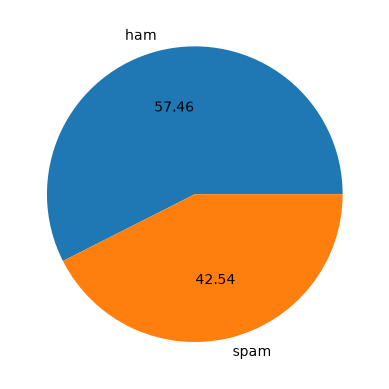

In [59]:
plt.pie(df['target'].value_counts(), labels = ['ham', 'spam'], autopct = '%0.2f')
plt.show()

In [60]:
import nltk

In [61]:
#to use word tokernizer to separate words
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [62]:
#fetch number of characters
#df['text'].apply(len)
df['num_characters'] = df['text'].apply(len)

In [63]:
df.head()

,target,text,num_characters
0,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
1,1,FreeMsg Hey there darling it's been 3 week's n...,148
2,1,WINNER!! As a valued network customer you have...,158
3,1,Had your mobile 11 months or more? U R entitle...,154
4,1,"SIX chances to win CASH! From 100 to 20,000 po...",136


In [64]:
#fetch number of words
#df['text'].apply(lambda x:nltk.word_tokenize(x))
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [65]:
df.head()

,target,text,num_characters,num_words
0,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
1,1,FreeMsg Hey there darling it's been 3 week's n...,148,39
2,1,WINNER!! As a valued network customer you have...,158,32
3,1,Had your mobile 11 months or more? U R entitle...,154,31
4,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31


In [66]:
#fetch number of sentences
#df['text'].apply(lambda x:nltk.sent_tokenize(x))
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [67]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
1,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4
2,1,WINNER!! As a valued network customer you have...,158,32,5
3,1,Had your mobile 11 months or more? U R entitle...,154,31,3
4,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3


In [68]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,7859.000000,7859.000000,7859.000000
mean,445.177376,81.031556,1.700980
std,1457.846025,247.459442,1.313211
min,2.000000,1.000000,1.000000
25%,46.000000,11.000000,1.000000
50%,113.000000,24.000000,1.000000
75%,310.000000,58.000000,2.000000
max,32759.000000,6257.000000,38.000000


In [69]:
#check only for ham messages
df[df['target']==0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [70]:
#check only for spam messages
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,3343.000000,3343.000000,3343.000000
mean,951.377505,167.357164,1.539934
std,2132.341306,361.614360,1.192990
min,5.000000,1.000000,1.000000
25%,156.000000,30.000000,1.000000
50%,461.000000,82.000000,1.000000
75%,1036.500000,183.500000,1.000000
max,32759.000000,6257.000000,9.000000


In [71]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

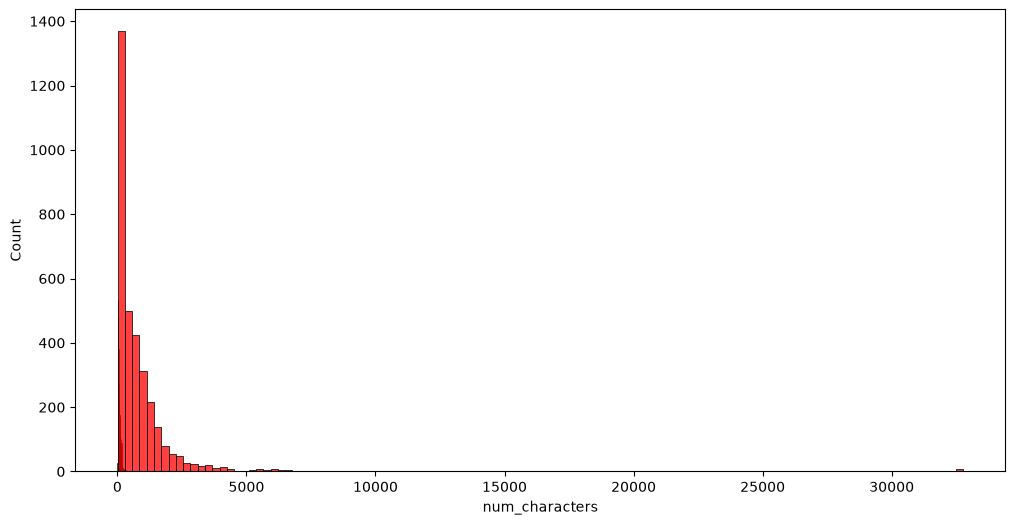

In [72]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target']==0]['num_characters'], color = 'green')
sns.histplot(df[df['target']==1]['num_characters'], color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

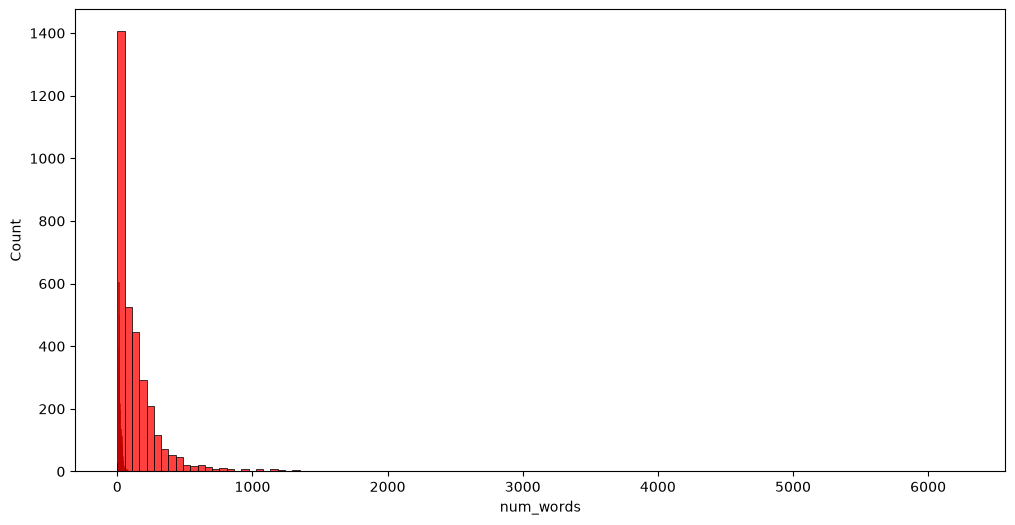

In [73]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target']==0]['num_words'], color = 'green')
sns.histplot(df[df['target']==1]['num_words'], color = 'red')

<Axes: xlabel='num_sentences', ylabel='Count'>

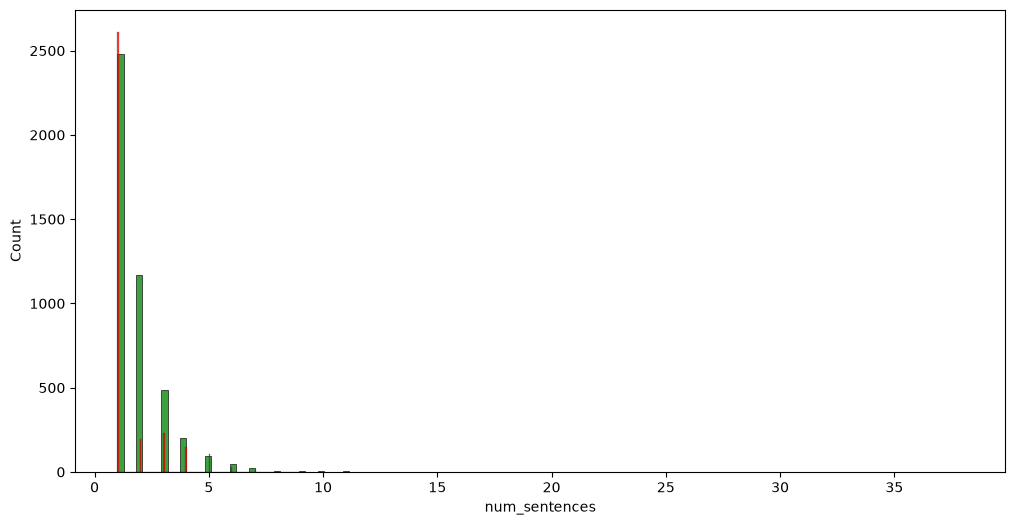

In [74]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target']==0]['num_sentences'], color = 'green')
sns.histplot(df[df['target']==1]['num_sentences'], color = 'red')

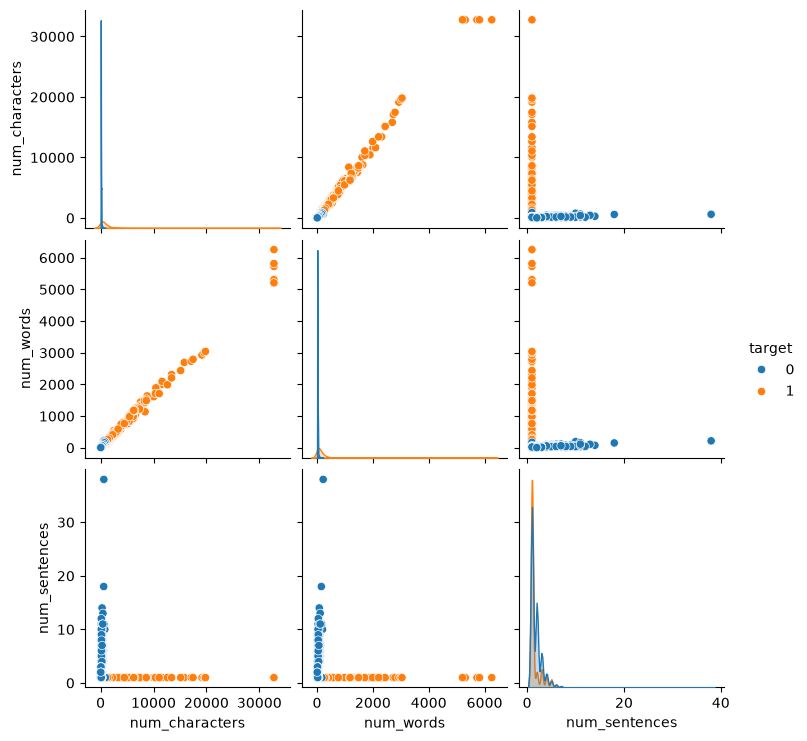

In [75]:
sns.pairplot(df, hue='target')

<Axes: >

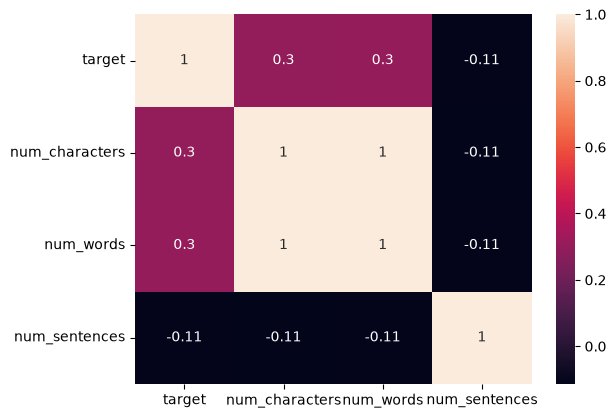

In [76]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

DATA PREPROCESSING